<a href="https://colab.research.google.com/github/leejsya/PyTorch/blob/main/BreastCancer_Classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 라이브러리 및 모듈 임포트

In [432]:
from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import numpy as np
import pandas as pd
# scaler 객체를 저장하는 도구
import joblib

# 2. 데이터 전처리

In [433]:
# scikitlearn에서 breast_cancer 데이터셋(np array) 가져오기
b_cancer = load_breast_cancer()

# 데이터셋 구조 확인용
df = pd.DataFrame(b_cancer.data, columns=b_cancer.feature_names)
df['target'] = b_cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [434]:
# input, target 설정
input_data = b_cancer.data.astype(np.float32)
target_data = b_cancer.target.astype(np.float32)

In [435]:
# Dataset 클래스
class BCancerDataset(Dataset):
  def __init__(self, input_data, target_data):
    self.input_data = input_data
    self.target_data = target_data

  def __len__(self):
    return len(self.input_data)

  def __getitem__(self, index):
    input_tensor = torch.tensor(self.input_data[index], dtype=torch.float32)
    target_tensor = torch.tensor(self.target_data[index], dtype=torch.float32)

    return input_tensor, target_tensor

In [436]:
# train/val/test - 0.8 : 0.1 : 0.1
train_input, temp_input, train_target, temp_target = train_test_split(input_data, target_data, test_size=0.2, random_state=5)
val_input, test_input, val_target, test_target = train_test_split(temp_input, temp_target, test_size=0.5, random_state=5)

scaler = StandardScaler()
scaler.fit(train_input)

train_input_scaled = scaler.transform(train_input)
val_input_scaled = scaler.transform(val_input)
test_input_scaled = scaler.transform(test_input)

train_dataset = BCancerDataset(train_input_scaled, train_target)
val_dataset = BCancerDataset(val_input_scaled, val_target)
test_dataset = BCancerDataset(test_input_scaled, test_target)

# batch shuffle과 dropout을 고정
torch.manual_seed(42)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=32)

# 3. 모델 정의 및 생성

In [437]:
class BCancerModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(30, 32)
    self.fc2 = nn.Linear(32, 16)
    self.fc3 = nn.Linear(16, 8)
    self.fc4 = nn.Linear(8, 1)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.relu(self.fc3(x))
    x = self.dropout(x)
    x = self.fc4(x)
    return x

model = BCancerModel()
# binary cross entropy + sigmoid
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

BCancerModel(
  (fc1): Linear(in_features=30, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

In [438]:
epochs = 17

for epoch in range(epochs):
    # training loop
    model.train()

    for train_batch in train_dataloader:
        x_train, y_train = train_batch[0].to(device), train_batch[1].to(device)

        logit = model(x_train).squeeze(-1)
        loss = loss_fn(logit, y_train)
        # autograd
        loss.backward()
        # update
        optimizer.step()
        # gradient 초기화
        optimizer.zero_grad()

    # validation
    model.eval()
    with torch.no_grad():
        val_losses = []
        for val_batch in val_dataloader:
            x_val, y_val = val_batch[0].to(device), val_batch[1].to(device)
            logit = model(x_val).squeeze(-1)
            loss = loss_fn(logit, y_val)
            val_losses.append(loss.item())

        val_loss_avg = sum(val_losses) / len(val_losses)
        print(f"epoch: {epoch+1}/{epochs}   validation loss: {val_loss_avg:.4f}")

epoch: 1/17   validation loss: 0.6755
epoch: 2/17   validation loss: 0.6225
epoch: 3/17   validation loss: 0.5493
epoch: 4/17   validation loss: 0.4619
epoch: 5/17   validation loss: 0.3852
epoch: 6/17   validation loss: 0.3201
epoch: 7/17   validation loss: 0.2633
epoch: 8/17   validation loss: 0.2132
epoch: 9/17   validation loss: 0.1753
epoch: 10/17   validation loss: 0.1512
epoch: 11/17   validation loss: 0.1366
epoch: 12/17   validation loss: 0.1306
epoch: 13/17   validation loss: 0.1242
epoch: 14/17   validation loss: 0.1218
epoch: 15/17   validation loss: 0.1190
epoch: 16/17   validation loss: 0.1177
epoch: 17/17   validation loss: 0.1170


In [439]:
# test
model.eval()
with torch.no_grad():
  preds = []
  targets = []
  for test_batch in test_dataloader:
    x_test, y_test = test_batch[0].to(device), test_batch[1].to(device)
    logit = model(x_test).squeeze(-1)
    preds.extend((logit > 0).cpu().numpy())
    targets.extend(y_test.cpu().numpy())

print(f"report:\n{classification_report(targets, preds)}")

report:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.98        21
         1.0       0.97      1.00      0.99        36

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



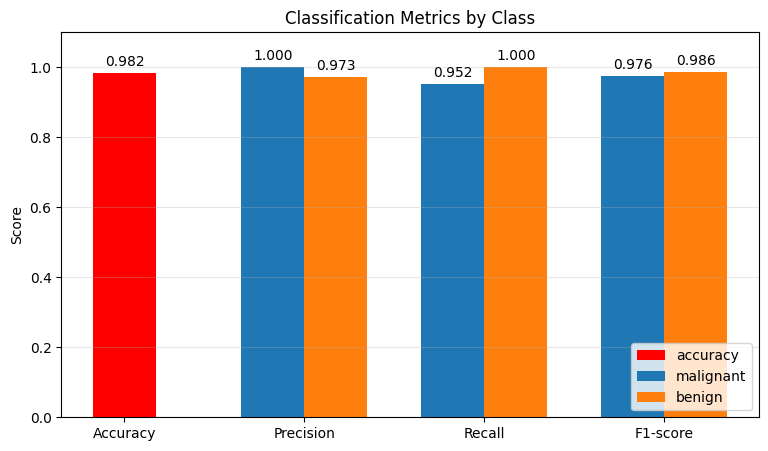

In [440]:
import matplotlib.pyplot as plt

report = classification_report(
    targets, preds, target_names=b_cancer.target_names, output_dict=True)

classes = ['malignant', 'benign']
metrics = ['precision', 'recall', 'f1-score']
accuracy = report['accuracy']

x = np.arange(len(metrics)) + 1
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

acc_bar = ax.bar(0, accuracy, width, color='red', label='accuracy')
ax.bar_label(acc_bar, fmt='%.3f', padding=3)

for i, cls in enumerate(classes):
    values = [report[cls][m] for m in metrics]
    bars = ax.bar(x + (i - 0.5) * width, values, width, label=cls)
    ax.bar_label(bars, fmt='%.3f', padding=3)

ax.set_xticks(np.arange(len(metrics) + 1), ['Accuracy', 'Precision', 'Recall', 'F1-score'])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Metrics by Class')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.show()

In [441]:
torch.save(model.state_dict(), 'model.pt')
joblib.dump(scaler, "scaler.pkl")

import sys, sklearn, torch, numpy as np, pandas as pd, joblib

versions = {
    "python": sys.version.split()[0],
    "scikit-learn": sklearn.__version__,
    "torch": torch.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "joblib": joblib.__version__,
}

with open("requirements.txt", "w") as f:
    for name, ver in versions.items():
        if name == "python":
            continue
        ver = ver.split("+")[0]
        f.write(f"{name}=={ver}\n")